In [117]:
from data_loader import daily_data_loader
df = daily_data_loader()

print(f'Available Features:')
print(df.columns.to_list())

Available Features:
['date', 'kwh', 'temp_mean', 'temp_min', 'temp_max', 'rhum_mean', 'rhum_min', 'rhum_max', 'prcp_sum', 'wspd_mean', 'wspd_min', 'wspd_max', 'pres_mean', 'wdir_mean', 'dayofweek', 'month', 'is_weekend', 'dayofweek_sin', 'dayofweek_cos', 'month_sin', 'month_cos', 'wdir_mean_sin', 'wdir_mean_cos']


In [118]:
import numpy as np

COMFORT = 18.0  # adjust to °C or °F depending on your data
df['hdd'] = np.clip(COMFORT - df['temp_mean'], 0, None)
df['cdd'] = np.clip(df['temp_mean'] - COMFORT, 0, None)
df['doy_sin'] = np.sin(2 * np.pi * df['date'].dt.dayofyear / 365.25)
df['doy_cos'] = np.cos(2 * np.pi * df['date'].dt.dayofyear / 365.25)
df['temp_x_rhum'] = df['temp_mean'] * df['rhum_mean']
df['temp_range'] = df['temp_max'] - df['temp_min']

In [119]:
FEATURE_COLS = [
    'temp_mean', 
    #'temp_min',
    #'temp_max',
    'temp_x_rhum',
    'temp_range',
    'hdd',
    'cdd',
    'rhum_mean', 
    'rhum_min', 
    'rhum_max',
    'prcp_sum', 
    'wspd_mean', 
    'wspd_min', 
    'wspd_max', 
    #'pres_mean', 
    #'is_weekend', 
    #'dayofweek_sin', 'dayofweek_cos', 
    #'month_sin', 'month_cos', 
    'wdir_mean_sin', 'wdir_mean_cos',
    'doy_sin', 'doy_cos'
]

TARGET_COL   = "kwh"

In [120]:
from sklearn.preprocessing import StandardScaler

# Sequential separation to prevent data leakage
X_data = df[FEATURE_COLS].values
y_data = df[TARGET_COL].values.reshape(-1, 1)  # Reshape required for scaling

split_idx = int(len(X_data) * 0.75)

scaler_X = StandardScaler()
scaler_X.fit(X_data[:split_idx])          # Learn the math from the past
X_scaled = scaler_X.transform(X_data)     # Apply the math to the whole timeline

scaler_y = StandardScaler()
scaler_y.fit(y_data[:split_idx])
y_scaled = scaler_y.transform(y_data)

X_train = X_scaled[:split_idx]
X_test  = X_scaled[split_idx:]
y_train = y_scaled[:split_idx]
y_test  = y_scaled[split_idx:]

print(f"Features:      {FEATURE_COLS}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}  (mean={y_train.mean():.3f} kWh, std={y_train.std():.3f})")
print(f"y_test  shape: {y_test.shape}  (mean={y_test.mean():.3f} kWh, std={y_test.std():.3f})")

Features:      ['temp_mean', 'temp_x_rhum', 'temp_range', 'hdd', 'cdd', 'rhum_mean', 'rhum_min', 'rhum_max', 'prcp_sum', 'wspd_mean', 'wspd_min', 'wspd_max', 'wdir_mean_sin', 'wdir_mean_cos', 'doy_sin', 'doy_cos']
X_train shape: (1161, 16)
X_test shape:  (388, 16)
y_train shape: (1161, 1)  (mean=0.000 kWh, std=1.000)
y_test  shape: (388, 1)  (mean=0.320 kWh, std=1.057)


In [121]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)
y_test_t  = torch.tensor(y_test, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)

# Model
class MLP(nn.Module):
    def __init__(self, n_features, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 64),    # input layer: n_features → 12 neurons
            nn.ReLU(),                    # activation: zero out negatives
            nn.Dropout(dropout),             # randomly zero 5% of neurons during training (regularization)
            nn.Linear(64, 32),             # hidden layer
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)               # output layer
        )
    
    def forward(self, x):
        return self.net(x)              # forward pass: input flows through all layers sequentially


In [122]:
model = MLP(X_train_t.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
#scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
criterion = nn.HuberLoss()

train_losses = []
test_losses = []

n_epochs = 50

for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0
    for Xb, yb in train_loader:
        pred = model(Xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_loader))
    
    model.eval()
    with torch.no_grad():
        test_loss = criterion(model(X_test_t), y_test_t).item()
    test_losses.append(test_loss)
    
    #scheduler.step(test_loss)
    
    if (epoch + 1) % 2 == 0:
        print(f"Epoch {epoch+1:3d} | Test MSE: {test_loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")


Epoch   2 | Test MSE: 0.4253 | LR: 0.000100
Epoch   4 | Test MSE: 0.3974 | LR: 0.000100
Epoch   6 | Test MSE: 0.3690 | LR: 0.000100
Epoch   8 | Test MSE: 0.3412 | LR: 0.000100
Epoch  10 | Test MSE: 0.3149 | LR: 0.000100
Epoch  12 | Test MSE: 0.2880 | LR: 0.000100
Epoch  14 | Test MSE: 0.2631 | LR: 0.000100
Epoch  16 | Test MSE: 0.2377 | LR: 0.000100
Epoch  18 | Test MSE: 0.2136 | LR: 0.000100
Epoch  20 | Test MSE: 0.1922 | LR: 0.000100
Epoch  22 | Test MSE: 0.1768 | LR: 0.000100
Epoch  24 | Test MSE: 0.1676 | LR: 0.000100
Epoch  26 | Test MSE: 0.1597 | LR: 0.000100
Epoch  28 | Test MSE: 0.1513 | LR: 0.000100
Epoch  30 | Test MSE: 0.1492 | LR: 0.000100
Epoch  32 | Test MSE: 0.1476 | LR: 0.000100
Epoch  34 | Test MSE: 0.1458 | LR: 0.000100
Epoch  36 | Test MSE: 0.1442 | LR: 0.000100
Epoch  38 | Test MSE: 0.1442 | LR: 0.000100
Epoch  40 | Test MSE: 0.1437 | LR: 0.000100
Epoch  42 | Test MSE: 0.1436 | LR: 0.000100
Epoch  44 | Test MSE: 0.1456 | LR: 0.000100
Epoch  46 | Test MSE: 0.1424 | L

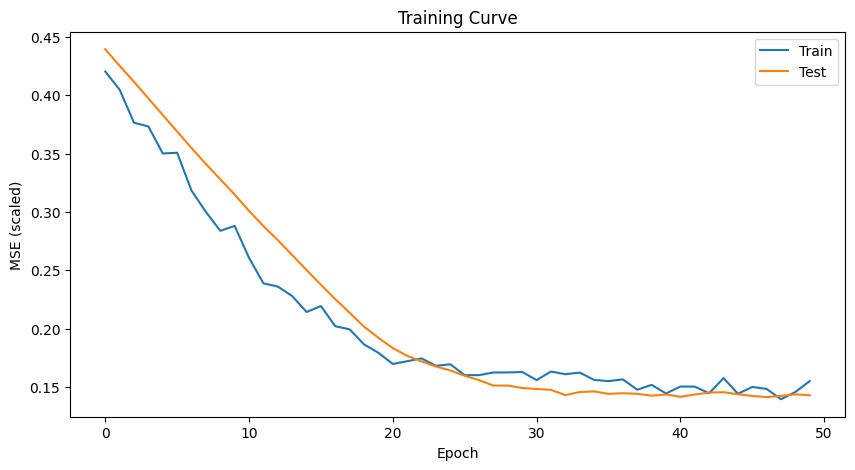

In [123]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train')
plt.plot(test_losses, label='Test')
plt.xlabel('Epoch')
plt.ylabel('MSE (scaled)')
plt.legend()
plt.title('Training Curve')
plt.show()

MLP: R²=0.719  RMSE=12.69 kWh  MAE=9.30 kWh


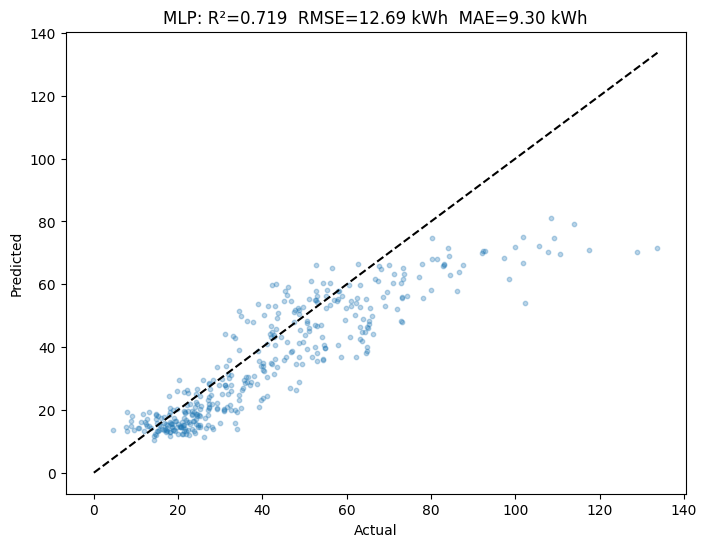

In [124]:
import numpy as np

model.eval()
with torch.no_grad():
    pred_scaled = model(X_test_t).numpy()
    pred_kwh = scaler_y.inverse_transform(pred_scaled)
    test_kwh = scaler_y.inverse_transform(y_test)
    
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
rmse = np.sqrt(mean_squared_error(test_kwh, pred_kwh))
r2 = r2_score(test_kwh, pred_kwh)
mae = mean_absolute_error(test_kwh, pred_kwh)

plt.figure(figsize=(8, 6))
plt.scatter(test_kwh, pred_kwh, alpha=0.3, s=10)
plt.plot([0, test_kwh.max()], [0, test_kwh.max()], 'k--')  # perfect prediction line
plt.xlabel('Actual')
plt.ylabel('Predicted')

print(f'MLP: R²={r2:.3f}  RMSE={rmse:.2f} kWh  MAE={mae:.2f} kWh')
plt.title(f'MLP: R²={r2:.3f}  RMSE={rmse:.2f} kWh  MAE={mae:.2f} kWh')
plt.show()

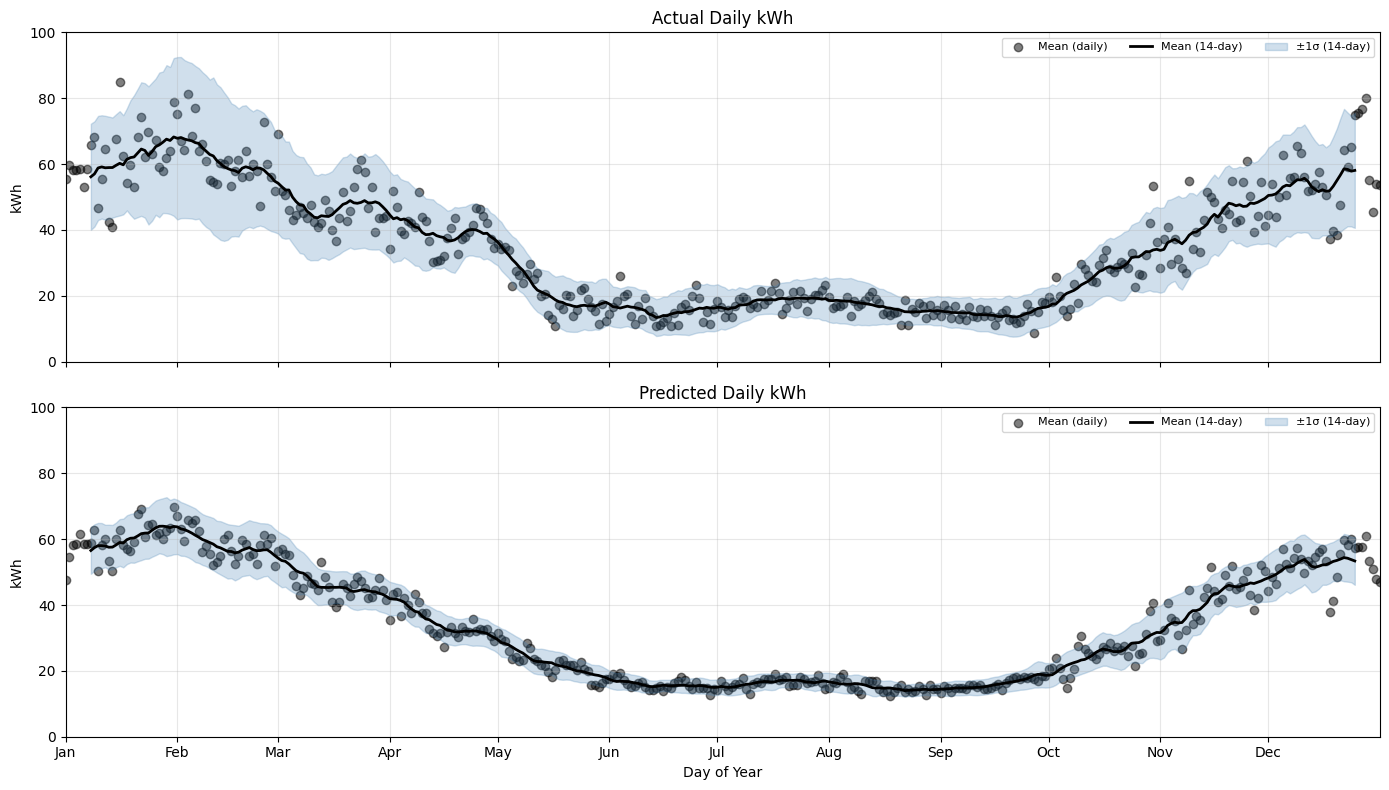

In [142]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import calendar
import numpy as np

# --- Generate predictions ---
model.eval()
with torch.no_grad():
    X_all_tensor = torch.tensor(X_scaled, dtype=torch.float32)
    all_preds_scaled = model(X_all_tensor).numpy()
all_preds_kwh = scaler_y.inverse_transform(all_preds_scaled).flatten()

# --- Collect per-year traces into a (366, n_years) grid ---
years = sorted(df["date"].dt.year.unique())

def build_doy_matrix(values):
    """Stack each year's daily values into columns aligned by day-of-year."""
    matrix = np.full((366, len(years)), np.nan)
    for i, yr in enumerate(years):
        mask = df["date"].dt.year == yr
        doy = df.loc[mask, "date"].dt.dayofyear.values - 1  # 0-indexed
        matrix[doy, i] = values[mask]
    return matrix

actual_matrix = build_doy_matrix(df[TARGET_COL].values)
pred_matrix   = build_doy_matrix(all_preds_kwh)

doy_axis = np.arange(1, 367)

# --- Plot ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, matrix, title in [(ax1, actual_matrix, "Actual Daily kWh"),
                           (ax2, pred_matrix,   "Predicted Daily kWh")]:
    mean = np.nanmean(matrix, axis=1)
    std  = np.nanstd(matrix, axis=1)

    # # Faint individual year lines
    # cmap = plt.cm.viridis
    # for i, yr in enumerate(years):
    #     ax.plot(doy_axis, matrix[:, i], color=cmap(i / max(len(years)-1, 1)),
    #             linewidth=0.6, alpha=0.3, label=str(yr))

    # n-day moving average
    n_days = 14
    half = n_days // 2
    mean_smooth = np.convolve(mean, np.ones(n_days)/n_days, mode='same')

    # Chop edges where convolution doesn't have full window
    doy_smooth = doy_axis[half:-half]
    mean_smooth = mean_smooth[half:-half]

    ax.scatter(doy_axis, mean, color="black", alpha=0.5, label="Mean (daily)")
    ax.plot(doy_smooth, mean_smooth, color="black", linewidth=2, label=f"Mean ({n_days}-day)")
    
    std_smooth  = np.convolve(std, np.ones(n_days)/n_days, mode='same')
    std_smooth = std_smooth[half:-half]
    
    ax.fill_between(doy_smooth, mean_smooth - std_smooth, mean_smooth + std_smooth,
                    color="steelblue", alpha=0.25, label=f"±1σ ({n_days}-day)")

    ax.set_ylabel("kWh")
    ax.set_title(title)
    ax.legend(loc="upper right", fontsize=8, ncol=min(len(years) + 2, 7))
    ax.grid(True, alpha=0.3)

month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = list(calendar.month_abbr[1:])
for ax in (ax1, ax2):
    ax.xaxis.set_major_locator(mticker.FixedLocator(month_starts))
    ax.xaxis.set_major_formatter(mticker.FixedFormatter(month_labels))
    ax.set_xlim(1, 366)
    ax.set_ylim(0,100)

ax2.set_xlabel("Day of Year")
plt.tight_layout()
plt.show()